<a href="https://colab.research.google.com/github/cedaco/RGV-Obesity-Project/blob/main/Hidalgo_Obesity_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [50]:
df = pd.read_csv("https://data.cdc.gov/resource/i46a-9kgh.csv?$limit=50000")
cols_of_interest = [
    'stateabbr',
    'countyname',
    'totalpopulation',
    'obesity_crudeprev',
    'diabetes_crudeprev',
    'lpa_crudeprev',
    'access2_crudeprev',
    'bphigh_crudeprev',
    'csmoking_crudeprev',
    'sleep_crudeprev',
    'depression_crudeprev',
    'cholscreen_crudeprev',
]
df = df[cols_of_interest]
df = df.dropna()
rgv = df[(df['stateabbr'] == 'TX') & (df['countyname'].isin(['Hidalgo', 'Cameron']))]

In [32]:
# National and Texas averages
national_avg = df.mean(numeric_only=True)
texas_avg = df[df['stateabbr'] == 'TX'].mean(numeric_only=True)

comparison = pd.DataFrame({
    'Hidalgo': rgv[rgv['countyname'] == 'Hidalgo'].mean(numeric_only=True),
    'Cameron': rgv[rgv['countyname'] == 'Cameron'].mean(numeric_only=True),
    'Texas Avg': texas_avg,
    'National Avg': national_avg
}).drop('totalpopulation')

print(comparison.round(2))


                      Hidalgo  Cameron  Texas Avg  National Avg
obesity_crudeprev        44.2     40.3      37.42         37.42
diabetes_crudeprev       17.4     18.3      14.62         13.64
lpa_crudeprev            37.5     36.9      31.28         28.45
access2_crudeprev        37.4     35.9      20.36         11.14
bphigh_crudeprev         33.4     34.0      37.66         38.72
csmoking_crudeprev       13.3     13.0      14.70         15.82
sleep_crudeprev          40.4     39.8      38.24         36.02
depression_crudeprev     20.2     18.9      22.11         22.90
cholscreen_crudeprev     80.2     82.4      84.66         85.44


In [34]:
# Where do RGV counties rank nationally for obesity?
df_ranked = df.copy()
df_ranked['obesity_rank'] = df_ranked['obesity_crudeprev'].rank(ascending=False)
df_ranked['obesity_percentile'] = df_ranked['obesity_crudeprev'].rank(pct=True) * 100

rgv_ranks = df_ranked[df_ranked['countyname'].isin(['Hidalgo', 'Cameron']) & (df_ranked['stateabbr'] == 'TX')]
print(rgv_ranks[['countyname', 'obesity_crudeprev', 'obesity_rank', 'obesity_percentile']].round(2))

     countyname  obesity_crudeprev  obesity_rank  obesity_percentile
636     Cameron               40.3         782.0               73.58
1852    Hidalgo               44.2         153.5               94.84


In [42]:
hidalgo_obesity = df[(df['stateabbr'] == 'TX') & (df['countyname'] == 'Hidalgo')]['obesity_crudeprev'].values[0]
texas_obesity = df[df['stateabbr'] == 'TX']['obesity_crudeprev'].dropna()
national_obesity = df['obesity_crudeprev'].dropna()

# Hidalgo vs Texas
t_stat, p_value = stats.ttest_1samp(texas_obesity, hidalgo_obesity)
print(f"Hidalgo vs Texas:    t={t_stat:.3f}, p={p_value:.4f}")

# Hidalgo vs National
t_stat, p_value = stats.ttest_1samp(national_obesity, hidalgo_obesity)
print(f"Hidalgo vs National: t={t_stat:.3f}, p={p_value:.4f}")

Hidalgo vs Texas:    t=-37.246, p=0.0000
Hidalgo vs National: t=-77.495, p=0.0000


LINEAR REGRESSION: PREDICTING HIDALGO OBESITY VS ACTUAL

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Features and target
X = df[['diabetes_crudeprev', 'lpa_crudeprev', 'access2_crudeprev',
        'bphigh_crudeprev', 'csmoking_crudeprev', 'sleep_crudeprev',
        'depression_crudeprev', 'cholscreen_crudeprev']]
y = df['obesity_crudeprev']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {mean_squared_error(y_test, y_pred)**0.5:.4f}")

# Coefficients
coef_df = pd.DataFrame({'Variable': X.columns, 'Coefficient': model.coef_}).sort_values('Coefficient', ascending=False)
print(coef_df.round(4))

R² Score: 0.6595
RMSE: 2.8374
               Variable  Coefficient
1         lpa_crudeprev       0.3793
4    csmoking_crudeprev       0.2465
3      bphigh_crudeprev       0.2390
5       sleep_crudeprev       0.0876
6  depression_crudeprev      -0.0296
0    diabetes_crudeprev      -0.0923
2     access2_crudeprev      -0.1594
7  cholscreen_crudeprev      -0.2727


In [47]:
hidalgo_X = df[(df['stateabbr'] == 'TX') & (df['countyname'] == 'Hidalgo')][X.columns]
hidalgo_pred = model.predict(hidalgo_X)
hidalgo_actual = df[(df['stateabbr'] == 'TX') & (df['countyname'] == 'Hidalgo')]['obesity_crudeprev'].values[0]

print(f"Predicted: {hidalgo_pred[0]:.2f}%")
print(f"Actual:    {hidalgo_actual:.2f}%")
print(f"Residual:  {hidalgo_actual - hidalgo_pred[0]:.2f}%")

Predicted: 36.32%
Actual:    44.20%
Residual:  7.88%


LOGISTIC REGRESSIONS

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Create binary label: 1 = high obesity, 0 = low obesity
median_obesity = df['obesity_crudeprev'].median()
print(f"National median obesity: {median_obesity:.2f}%")

df['high_obesity'] = (df['obesity_crudeprev'] > median_obesity).astype(int)

# Check Hidalgo's label
hidalgo_label = df[(df['stateabbr'] == 'TX') & (df['countyname'] == 'Hidalgo')]['high_obesity'].values[0]
print(f"Hidalgo classified as high obesity: {hidalgo_label}")

# Features and target
X = df[['diabetes_crudeprev', 'lpa_crudeprev', 'access2_crudeprev',
        'bphigh_crudeprev', 'csmoking_crudeprev', 'sleep_crudeprev',
        'depression_crudeprev', 'cholscreen_crudeprev']]
y = df['high_obesity']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Evaluate
y_pred = log_model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

National median obesity: 37.90%
Hidalgo classified as high obesity: 1
              precision    recall  f1-score   support

           0       0.77      0.84      0.80       293
           1       0.82      0.76      0.79       299

    accuracy                           0.80       592
   macro avg       0.80      0.80      0.80       592
weighted avg       0.80      0.80      0.80       592

Confusion Matrix:
[[245  48]
 [ 73 226]]


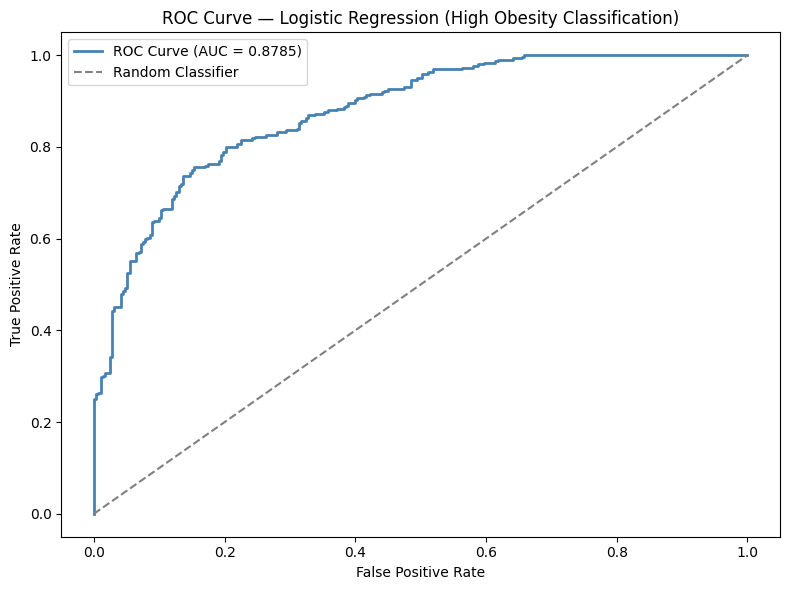

In [49]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability scores instead of just 0/1 predictions
y_prob = log_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (High Obesity Classification)')
plt.legend()
plt.tight_layout()
plt.show()